# TGNValueDataset Testing

This notebook demonstrates:
1. Loading training configuration from `configs/training/trigo-gpt2-value.yaml`
2. Creating TGNValueDataset with value score extraction
3. Inspecting samples with value_score and move_end_positions
4. Creating dataloader with custom collate function
5. Analyzing batch statistics and value distributions
6. Visualizing move positions and tokenization

## 1. Environment Setup

In [1]:
import sys
import os

sys.path.append('..')
os.chdir('..')

In [2]:
import sys
from pathlib import Path

import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from omegaconf import OmegaConf

# Add project root to path
project_root = Path.cwd()
sys.path.insert(0, str(project_root))

from trigor.data.tgn_value_dataset import TGNValueDataset

print(f"Project root: {project_root}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

Registered dataset: TGNDataset
Registered dataset: TGNValueDataset
Project root: /home/camus/work/trigoRL
PyTorch version: 2.9.0+cu128
CUDA available: True
CUDA device: NVIDIA GeForce RTX 3090


## 2. Load Configuration

Load the training configuration with TGNValueDataset from YAML file.

In [3]:
from datetime import datetime

# Load configuration
config_path = project_root / "configs/dataset/tgn_value.local.yaml"
cfg = OmegaConf.load(config_path)

# Register custom OmegaConf resolver for date
OmegaConf.register_new_resolver("date", lambda: datetime.now().strftime("%Y%m%d"))

# Register custom resolver to remove .local suffix from config names
OmegaConf.register_new_resolver(
    "remove_local_suffix",
    lambda s: s[:-6] if s.endswith('.local') else s
)

# Register Hydra resolvers for notebook environment
def hydra_resolver(path: str) -> str:
    """Mock Hydra resolver for notebook environment."""
    if path == "job.config_name":
        return config_path.stem
    elif path == "runtime.cwd":
        return str(project_root)
    else:
        return ""

OmegaConf.register_new_resolver("hydra", hydra_resolver)

# Resolve paths
OmegaConf.update(cfg, "paths.root", str(project_root))
try:
    OmegaConf.resolve(cfg)
except Exception:
    pass  # Skip resolution if there are Hydra-specific resolvers

print("Configuration loaded successfully!")
print("\nData configuration:")
print(f"  Type: {cfg.data.type}")
print(f"  Data dir: {cfg.data.data_dir}")
print(f"  Max length: {cfg.data.max_length}")
print(f"  Parse value: {cfg.data.parse_value}")
print(f"  Batch size: {cfg.data.loader.batch_size}")
print(f"  Train split: {cfg.data.train_split}")
print(f"  Val split: {cfg.data.val_split}")

Configuration loaded successfully!

Data configuration:
  Type: TGNValueDataset
  Data dir: /home/camus/work/trigo/trigo-web/tools/output/selfplay
  Max length: 8192
  Parse value: True
  Batch size: 1
  Train split: *1..8/10
  Val split: 9/10


## 3. Load TGNValueDataset

Create TGNValueDataset which extends TGNDataset with value score extraction.

In [4]:
# Create dataset
print("Loading TGNValueDataset...")
dataset = TGNValueDataset.from_config(cfg.data)

print(f"\nDataset loaded successfully!")
print(f"  Total samples: {len(dataset)}")
print(f"  Tokenizer vocab size: {dataset.tokenizer.get_vocab_size()}")
print(f"  Max length: {dataset.max_length}")
print(f"  Parse value enabled: {dataset.parse_value}")

print(f"\nTokenizer special tokens:")
print(f"  PAD token ID: {dataset.tokenizer.PAD_ID}")
print(f"  START token ID: {dataset.tokenizer.START_ID}")
print(f"  END token ID: {dataset.tokenizer.END_ID}")
print(f"  VALUE token ID: {dataset.tokenizer.VALUE_ID}")

Loading TGNValueDataset...
Loaded 93 TGN files from /home/camus/work/trigo/trigo-web/tools/output/selfplay

Dataset loaded successfully!
  Total samples: 93
  Tokenizer vocab size: 128
  Max length: 8192
  Parse value enabled: True

Tokenizer special tokens:
  PAD token ID: 0
  START token ID: 1
  END token ID: 2
  VALUE token ID: 3


## 4. Inspect Dataset Samples

Examine the structure of individual samples, focusing on value-related fields.

In [5]:
# Inspect a single sample
print("\n" + "="*80)
print("Sample Inspection")
print("="*80)

sample_idx = 0
sample = dataset[sample_idx]

print(f"\nSample {sample_idx}:")
print(f"  Input IDs shape: {sample['input_ids'].shape}")
print(f"  Labels shape: {sample['labels'].shape}")
print(f"  Attention mask shape: {sample['attention_mask'].shape}")
print(f"  Value score shape: {sample['value_score'].shape} (scalar)")
print(f"  Move end positions shape: {sample['move_end_positions'].shape}")

print(f"\n  Value score: {sample['value_score'].item():.1f}")
print(f"  Number of moves: {len(sample['move_end_positions'])}")
print(f"  Move end positions: {sample['move_end_positions'].tolist()[:15]}{'...' if len(sample['move_end_positions']) > 15 else ''}")

print(f"\n  First 20 input tokens: {sample['input_ids'][:20].tolist()}")
print(f"  First 20 labels: {sample['labels'][:20].tolist()}")
print(f"  First 20 attention mask: {sample['attention_mask'][:20].tolist()}")

# Count non-padding tokens
non_pad_count = (sample['attention_mask'] == 1).sum().item()
print(f"\n  Non-padding tokens: {non_pad_count} / {sample['input_ids'].shape[0]}")
print(f"  Padding ratio: {(1 - non_pad_count / sample['input_ids'].shape[0]) * 100:.2f}%")


Sample Inspection

Sample 0:
  Input IDs shape: torch.Size([8191])
  Labels shape: torch.Size([8191])
  Attention mask shape: torch.Size([8191])
  Value score shape: torch.Size([]) (scalar)
  Move end positions shape: torch.Size([15])

  Value score: 4.0
  Number of moves: 15
  Move end positions: [19, 22, 28, 31, 37, 40, 46, 49, 55, 58, 64, 67, 73, 76, 84]

  First 20 input tokens: [1, 91, 66, 111, 97, 114, 100, 32, 53, 120, 51, 93, 10, 10, 49, 46, 32, 98, 97, 32]
  First 20 labels: [91, 66, 111, 97, 114, 100, 32, 53, 120, 51, 93, 10, 10, 49, 46, 32, 98, 97, 32, 98]
  First 20 attention mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

  Non-padding tokens: 91 / 8191
  Padding ratio: 98.89%


## 5. View Original TGN Text

Display the original TGN file content for the sample.

In [6]:
# Get the original text
file_path = dataset.files[sample_idx]
text = file_path.read_text(encoding='utf-8', errors='replace')

print("\n" + "="*80)
print(f"Original TGN File: {file_path.name}")
print("="*80)
print(text)
print("="*80)


Original TGN File: game_011c8df05738e46b.tgn
[Board 5x3]

1. ba bz
2. zz yz
3. aa z0
4. za a0
5. 0z 00
6. ya zz
7. 0a b0
8. Pass
; +4



## 6. Analyze Move Position Tokenization

Verify that move end positions correspond to actual move boundaries in the tokenized text.

In [8]:
print("\n" + "="*80)
print("Move Position Analysis")
print("="*80)

# Parse the TGN file again to get moves
from trigor.data.tgn_value_dataset import parse_tgn_file

moves, score, move_end_positions = parse_tgn_file(text, dataset.tokenizer)

print(f"\nParsed {len(moves)} moves from TGN file")
print(f"Game score: {score:.1f}")
print(f"\nFirst 10 moves:")
for i, (move, pos) in enumerate(zip(moves, move_end_positions)):
    print(f"  Move {i+1}: '{move}' ends at token position {pos}")

# Verify positions are correct by decoding
print(f"\nVerifying move positions (first 5 moves):")
for i in range(min(5, len(moves))):
    pos = move_end_positions[i]
    # Get tokens up to this position
    tokens_up_to_move = sample['input_ids'][:pos+1]
    decoded = dataset.tokenizer.decode(tokens_up_to_move)
    # Show last 30 characters
    excerpt = decoded[-30:] if len(decoded) > 30 else decoded
    print(f"\n  Move {i+1}: '{moves[i]}' at position {pos}")
    print(f"    Context: ...{repr(excerpt)}")


Move Position Analysis

Parsed 15 moves from TGN file
Game score: 4.0

First 10 moves:
  Move 1: 'ba' ends at token position 19
  Move 2: 'bz' ends at token position 22
  Move 3: 'zz' ends at token position 28
  Move 4: 'yz' ends at token position 31
  Move 5: 'aa' ends at token position 37
  Move 6: 'z0' ends at token position 40
  Move 7: 'za' ends at token position 46
  Move 8: 'a0' ends at token position 49
  Move 9: '0z' ends at token position 55
  Move 10: '00' ends at token position 58
  Move 11: 'ya' ends at token position 64
  Move 12: 'zz' ends at token position 67
  Move 13: '0a' ends at token position 73
  Move 14: 'b0' ends at token position 76
  Move 15: 'Pass' ends at token position 84

Verifying move positions (first 5 moves):

  Move 1: 'ba' at position 19
    Context: ...'[Board 5x3]\n\n1. ba '

  Move 2: 'bz' at position 22
    Context: ...'[Board 5x3]\n\n1. ba bz\n'

  Move 3: 'zz' at position 28
    Context: ...'[Board 5x3]\n\n1. ba bz\n2. zz '

  Move 4: 'yz' at 

## 7. Dataset Statistics

Analyze value score distribution and move count statistics across the dataset.

In [9]:
print("\n" + "="*80)
print("Dataset Statistics")
print("="*80)

# Collect statistics from all samples
print("\nCollecting statistics from all samples...")
value_scores = []
num_moves = []
sequence_lengths = []

for i in range(len(dataset)):
    sample = dataset[i]
    value_scores.append(sample['value_score'].item())
    num_moves.append(len(sample['move_end_positions']))
    sequence_lengths.append((sample['attention_mask'] == 1).sum().item())

value_scores = np.array(value_scores)
num_moves = np.array(num_moves)
sequence_lengths = np.array(sequence_lengths)

print(f"\nValue Score Statistics:")
print(f"  Mean: {value_scores.mean():.2f}")
print(f"  Std: {value_scores.std():.2f}")
print(f"  Min: {value_scores.min():.1f}")
print(f"  Max: {value_scores.max():.1f}")
print(f"  Median: {np.median(value_scores):.1f}")

# Count wins/losses
black_wins = (value_scores < 0).sum()
white_wins = (value_scores > 0).sum()
draws = (value_scores == 0).sum()
print(f"\n  Black wins (score < 0): {black_wins} ({black_wins/len(value_scores)*100:.1f}%)")
print(f"  White wins (score > 0): {white_wins} ({white_wins/len(value_scores)*100:.1f}%)")
print(f"  Draws (score = 0): {draws} ({draws/len(value_scores)*100:.1f}%)")

print(f"\nMove Count Statistics:")
print(f"  Mean: {num_moves.mean():.1f}")
print(f"  Std: {num_moves.std():.1f}")
print(f"  Min: {num_moves.min()}")
print(f"  Max: {num_moves.max()}")
print(f"  Median: {int(np.median(num_moves))}")

print(f"\nSequence Length Statistics:")
print(f"  Mean: {sequence_lengths.mean():.1f}")
print(f"  Std: {sequence_lengths.std():.1f}")
print(f"  Min: {sequence_lengths.min()}")
print(f"  Max: {sequence_lengths.max()}")
print(f"  Median: {int(np.median(sequence_lengths))}")


Dataset Statistics


Value Score Statistics:
  Mean: 1.10
  Std: 10.33
  Min: -27.0
  Max: 20.0
  Median: 3.0

  Black wins (score < 0): 36 (38.7%)
  White wins (score > 0): 52 (55.9%)
  Draws (score = 0): 5 (5.4%)

Move Count Statistics:
  Mean: 13.6
  Std: 8.7
  Min: 2
  Max: 39
  Median: 12

Sequence Length Statistics:
  Mean: 88.2
  Std: 46.3
  Min: 27
  Max: 211
  Median: 84


## 8. Visualize Dataset Distributions

Create visualizations of value scores and move counts.

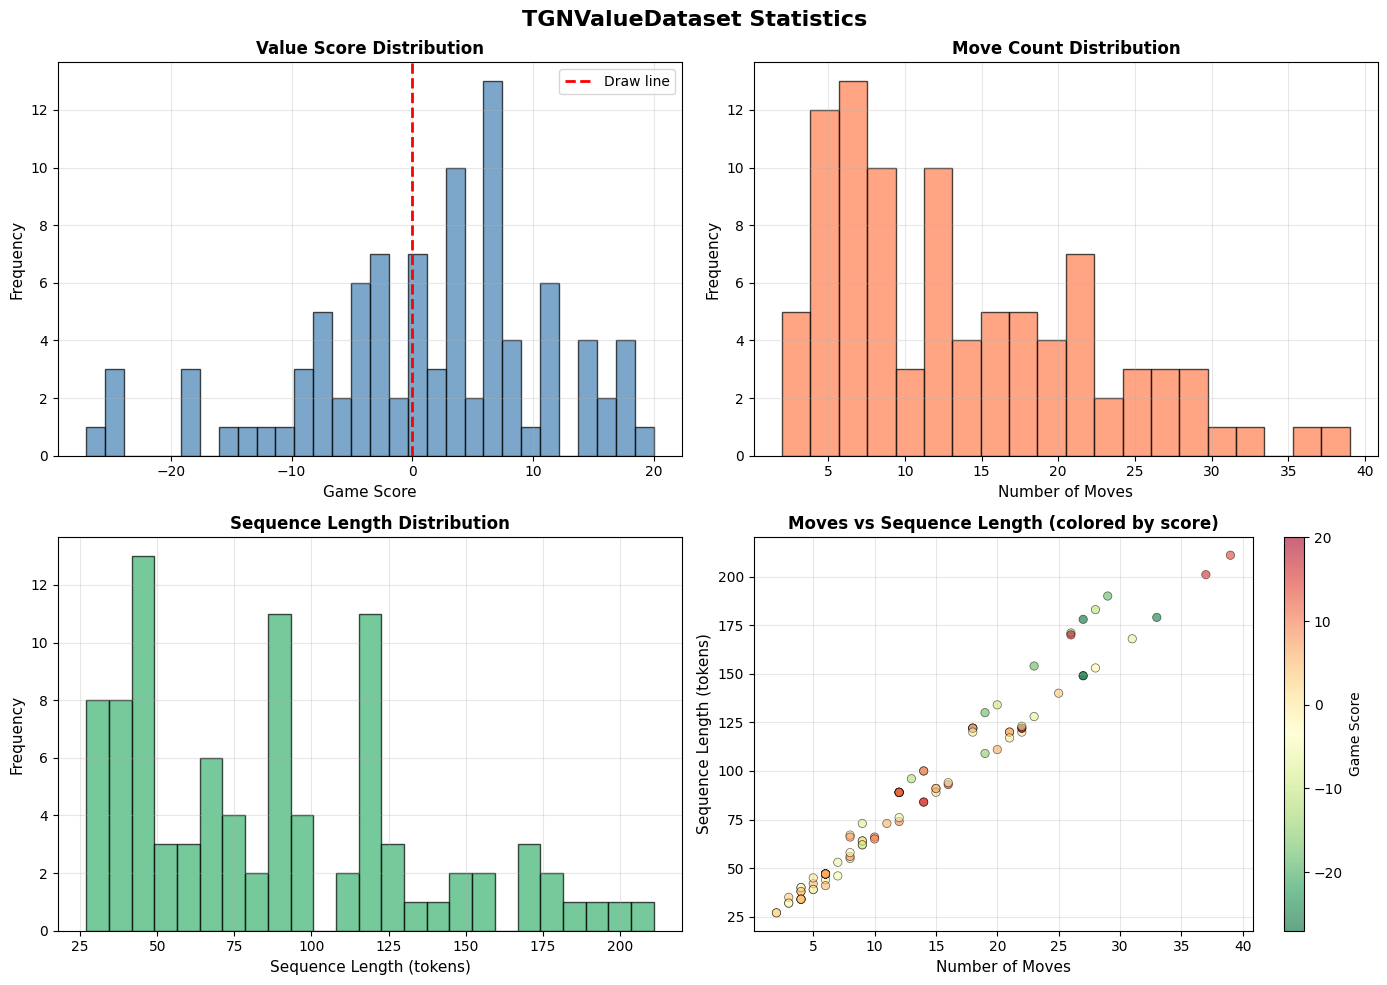


✓ Visualizations generated successfully!


In [10]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('TGNValueDataset Statistics', fontsize=16, fontweight='bold')

# 1. Value score distribution
ax1 = axes[0, 0]
ax1.hist(value_scores, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
ax1.axvline(0, color='red', linestyle='--', linewidth=2, label='Draw line')
ax1.set_xlabel('Game Score', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('Value Score Distribution', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# 2. Move count distribution
ax2 = axes[0, 1]
ax2.hist(num_moves, bins=20, color='coral', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Number of Moves', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('Move Count Distribution', fontsize=12, fontweight='bold')
ax2.grid(alpha=0.3)

# 3. Sequence length distribution
ax3 = axes[1, 0]
ax3.hist(sequence_lengths, bins=25, color='mediumseagreen', alpha=0.7, edgecolor='black')
ax3.set_xlabel('Sequence Length (tokens)', fontsize=11)
ax3.set_ylabel('Frequency', fontsize=11)
ax3.set_title('Sequence Length Distribution', fontsize=12, fontweight='bold')
ax3.grid(alpha=0.3)

# 4. Scatter: moves vs sequence length
ax4 = axes[1, 1]
scatter = ax4.scatter(num_moves, sequence_lengths, c=value_scores, cmap='RdYlGn_r', 
                      alpha=0.6, edgecolors='black', linewidth=0.5)
ax4.set_xlabel('Number of Moves', fontsize=11)
ax4.set_ylabel('Sequence Length (tokens)', fontsize=11)
ax4.set_title('Moves vs Sequence Length (colored by score)', fontsize=12, fontweight='bold')
ax4.grid(alpha=0.3)
plt.colorbar(scatter, ax=ax4, label='Game Score')

plt.tight_layout()
plt.show()

print("\n✓ Visualizations generated successfully!")

## 9. Create DataLoader

Create dataloader with custom collate function for batching.

In [11]:
# Create dataloader
dataloader = DataLoader(
    dataset,
    batch_size=4,  # Use batch size of 4 for demonstration
    shuffle=False,
    num_workers=0,  # Use 0 for notebook to avoid multiprocessing issues
    collate_fn=TGNValueDataset.collate_batch,
    pin_memory=False,
)

print(f"DataLoader created successfully!")
print(f"  Batch size: 4")
print(f"  Total batches: {len(dataloader)}")
print(f"  Collate function: TGNValueDataset.collate_batch")

DataLoader created successfully!
  Batch size: 4
  Total batches: 24
  Collate function: TGNValueDataset.collate_batch


## 10. Inspect Batch

Examine a batch to understand how samples are collated.

In [12]:
# Get one batch for testing
batch = next(iter(dataloader))

print("\n" + "="*80)
print("Batch Inspection")
print("="*80)

print(f"\nBatch shapes:")
print(f"  Input IDs: {batch['input_ids'].shape}")
print(f"  Labels: {batch['labels'].shape}")
print(f"  Attention mask: {batch['attention_mask'].shape}")
print(f"  Value score: {batch['value_score'].shape}")
print(f"  Move end positions: list of {len(batch['move_end_positions'])} tensors")

print(f"\nValue scores in batch:")
for i, score in enumerate(batch['value_score']):
    num_moves_i = len(batch['move_end_positions'][i])
    print(f"  Sample {i}: score={score.item():>6.1f}, moves={num_moves_i:>3d}")

print(f"\nBatch statistics:")
print(f"  Total tokens: {batch['input_ids'].numel()}")
print(f"  Valid tokens: {(batch['attention_mask'] == 1).sum().item()}")
print(f"  Padding tokens: {(batch['attention_mask'] == 0).sum().item()}")
print(f"  Padding ratio: {(batch['attention_mask'] == 0).sum().item() / batch['input_ids'].numel():.2%}")

print(f"\nValue score statistics:")
print(f"  Mean: {batch['value_score'].mean().item():.2f}")
print(f"  Std: {batch['value_score'].std().item():.2f}")
print(f"  Min: {batch['value_score'].min().item():.1f}")
print(f"  Max: {batch['value_score'].max().item():.1f}")


Batch Inspection

Batch shapes:
  Input IDs: torch.Size([4, 8191])
  Labels: torch.Size([4, 8191])
  Attention mask: torch.Size([4, 8191])
  Value score: torch.Size([4])
  Move end positions: list of 4 tensors

Value scores in batch:
  Sample 0: score=   4.0, moves= 15
  Sample 1: score=   2.0, moves= 15
  Sample 2: score= -18.0, moves= 23
  Sample 3: score=  -3.0, moves=  8

Batch statistics:
  Total tokens: 32764
  Valid tokens: 401
  Padding tokens: 32363
  Padding ratio: 98.78%

Value score statistics:
  Mean: -3.75
  Std: 9.95
  Min: -18.0
  Max: 4.0


## 11. Visualize Batch Sample

Visualize a single sample from the batch showing token positions and move boundaries.

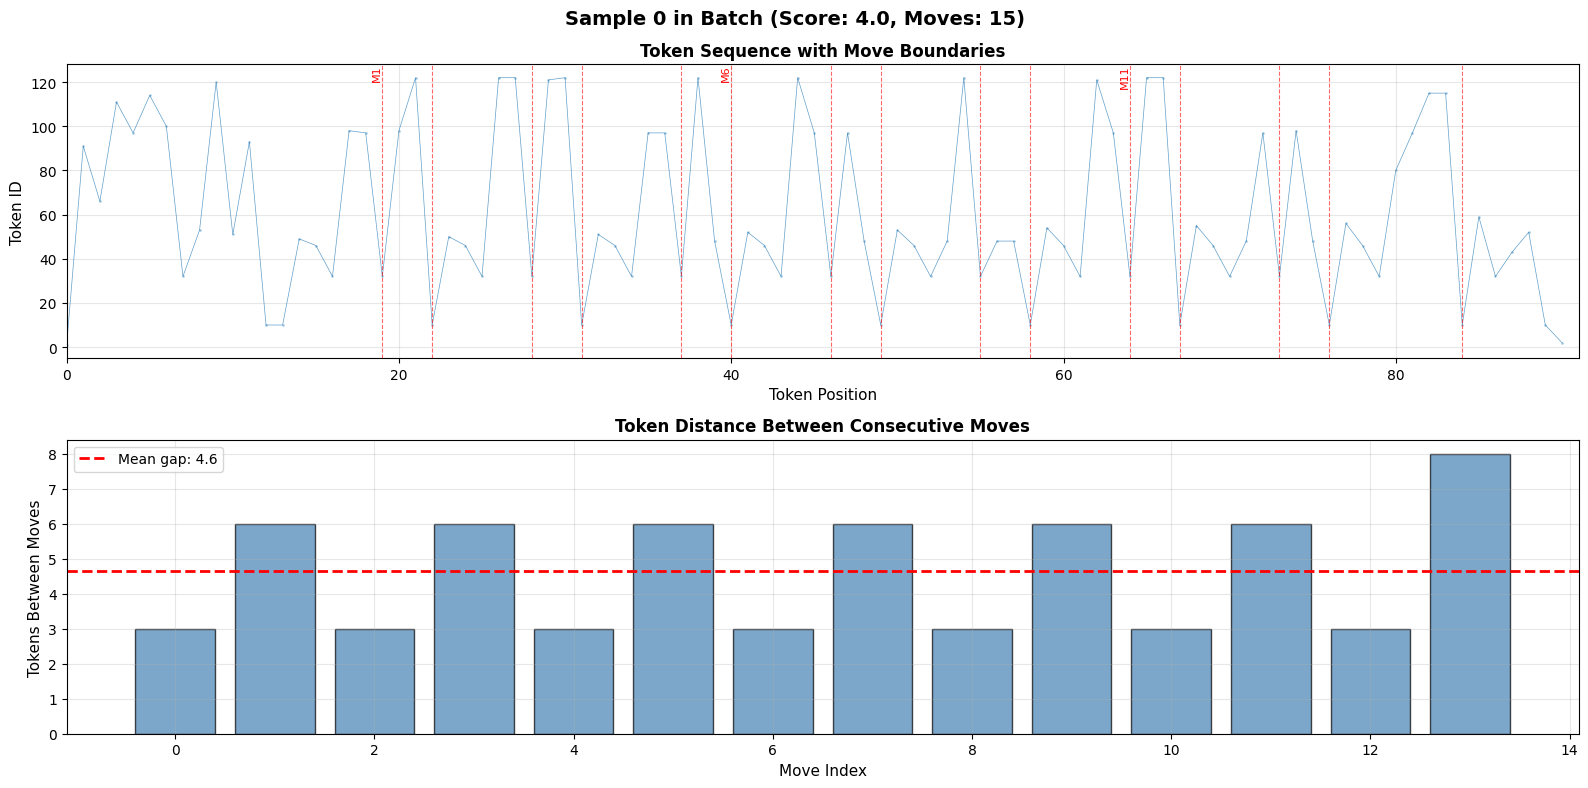


✓ Sample visualization complete!


In [13]:
# Visualize first sample in batch
sample_in_batch = 0

input_ids = batch['input_ids'][sample_in_batch]
attention_mask = batch['attention_mask'][sample_in_batch]
move_positions = batch['move_end_positions'][sample_in_batch].numpy()
score = batch['value_score'][sample_in_batch].item()

# Get valid tokens only
valid_length = (attention_mask == 1).sum().item()
valid_tokens = input_ids[:valid_length].numpy()

# Create visualization
fig, axes = plt.subplots(2, 1, figsize=(16, 8))
fig.suptitle(f'Sample {sample_in_batch} in Batch (Score: {score:.1f}, Moves: {len(move_positions)})', 
             fontsize=14, fontweight='bold')

# 1. Token sequence with move markers
ax1 = axes[0]
positions = np.arange(valid_length)
ax1.plot(positions, valid_tokens, linewidth=0.5, alpha=0.7)
ax1.scatter(positions, valid_tokens, s=1, alpha=0.3)

# Mark move end positions
for i, pos in enumerate(move_positions):
    if pos < valid_length:
        ax1.axvline(pos, color='red', linestyle='--', linewidth=0.8, alpha=0.6)
        if i % 5 == 0:  # Label every 5th move
            ax1.text(pos, ax1.get_ylim()[1], f'M{i+1}', 
                    rotation=90, va='top', ha='right', fontsize=8, color='red')

ax1.set_xlabel('Token Position', fontsize=11)
ax1.set_ylabel('Token ID', fontsize=11)
ax1.set_title('Token Sequence with Move Boundaries', fontsize=12, fontweight='bold')
ax1.grid(alpha=0.3)
ax1.set_xlim(0, min(valid_length, 200))  # Show first 200 tokens

# 2. Move position distribution
ax2 = axes[1]
if len(move_positions) > 1:
    move_gaps = np.diff(move_positions)
    ax2.bar(range(len(move_gaps)), move_gaps, color='steelblue', alpha=0.7, edgecolor='black')
    ax2.axhline(move_gaps.mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Mean gap: {move_gaps.mean():.1f}')
    ax2.set_xlabel('Move Index', fontsize=11)
    ax2.set_ylabel('Tokens Between Moves', fontsize=11)
    ax2.set_title('Token Distance Between Consecutive Moves', fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'Not enough moves to show gaps', 
            ha='center', va='center', transform=ax2.transAxes, fontsize=12)
    ax2.axis('off')

plt.tight_layout()
plt.show()

print("\n✓ Sample visualization complete!")

## 12. Examine Multiple Batches

Iterate through multiple batches to verify consistency.

In [14]:
print("\n" + "="*80)
print("Multi-Batch Analysis")
print("="*80)

num_batches_to_check = 5
print(f"\nExamining first {num_batches_to_check} batches...\n")

for batch_idx, batch in enumerate(dataloader):
    if batch_idx >= num_batches_to_check:
        break
    
    batch_size = batch['input_ids'].shape[0]
    avg_score = batch['value_score'].mean().item()
    avg_moves = np.mean([len(pos) for pos in batch['move_end_positions']])
    valid_tokens = (batch['attention_mask'] == 1).sum().item()
    
    print(f"Batch {batch_idx}:")
    print(f"  Size: {batch_size} samples")
    print(f"  Avg score: {avg_score:>7.2f}")
    print(f"  Avg moves: {avg_moves:>7.1f}")
    print(f"  Valid tokens: {valid_tokens:>6d}")
    print()

print("✓ All batches processed successfully!")


Multi-Batch Analysis

Examining first 5 batches...

Batch 0:
  Size: 4 samples
  Avg score:   -3.75
  Avg moves:    15.2
  Valid tokens:    401

Batch 1:
  Size: 4 samples
  Avg score:   -4.75
  Avg moves:    11.2
  Valid tokens:    326

Batch 2:
  Size: 4 samples
  Avg score:    7.00
  Avg moves:    15.8
  Valid tokens:    391

Batch 3:
  Size: 4 samples
  Avg score:    4.00
  Avg moves:    12.5
  Valid tokens:    338

Batch 4:
  Size: 4 samples
  Avg score:   -2.00
  Avg moves:    11.8
  Valid tokens:    343

✓ All batches processed successfully!


## 13. Summary

Summary of the TGNValueDataset exploration.

In [15]:
print("\n" + "="*80)
print("TEST SUMMARY")
print("="*80)

print(f"\n✓ Configuration loaded from: {config_path.name}")
print(f"✓ TGNValueDataset loaded: {len(dataset)} samples")
print(f"✓ Value scores extracted from all samples")
print(f"✓ Move end positions computed for all samples")
print(f"✓ DataLoader created with custom collate function")
print(f"✓ Batch inspection successful")

print(f"\nDataset Statistics:")
print(f"  Value scores: {value_scores.min():.1f} to {value_scores.max():.1f} (mean: {value_scores.mean():.2f})")
print(f"  Moves per game: {num_moves.min()} to {num_moves.max()} (mean: {num_moves.mean():.1f})")
print(f"  Sequence lengths: {sequence_lengths.min()} to {sequence_lengths.max()} tokens")

print(f"\nDataset Output Fields:")
print(f"  • input_ids: [batch_size, seq_len] - Input token IDs")
print(f"  • labels: [batch_size, seq_len] - Target token IDs")
print(f"  • attention_mask: [batch_size, seq_len] - Attention mask")
print(f"  • value_score: [batch_size] - Final game scores")
print(f"  • move_end_positions: List[Tensor] - Token positions where moves end (variable length)")

print(f"\nDataset is ready for training!")
print(f"\nNext steps:")
print(f"  1. Implement VALUE token injection in model")
print(f"  2. Create attention masks for VALUE tokens")
print(f"  3. Extract hidden states at VALUE token positions")
print(f"  4. Compute value loss (MSE) against value_score labels")
print(f"  5. Train dual-head network (policy + value)")


TEST SUMMARY

✓ Configuration loaded from: tgn_value.local.yaml
✓ TGNValueDataset loaded: 93 samples
✓ Value scores extracted from all samples
✓ Move end positions computed for all samples
✓ DataLoader created with custom collate function
✓ Batch inspection successful

Dataset Statistics:
  Value scores: -27.0 to 20.0 (mean: 1.10)
  Moves per game: 2 to 39 (mean: 13.6)
  Sequence lengths: 27 to 211 tokens

Dataset Output Fields:
  • input_ids: [batch_size, seq_len] - Input token IDs
  • labels: [batch_size, seq_len] - Target token IDs
  • attention_mask: [batch_size, seq_len] - Attention mask
  • value_score: [batch_size] - Final game scores
  • move_end_positions: List[Tensor] - Token positions where moves end (variable length)

Dataset is ready for training!

Next steps:
  1. Implement VALUE token injection in model
  2. Create attention masks for VALUE tokens
  3. Extract hidden states at VALUE token positions
  4. Compute value loss (MSE) against value_score labels
  5. Train dual